Joint probability (independent, 12 Loeb anomalies): 6.000000000000002e-29
Inflation factor required (1 / P_joint): 1.6666666666666662e+28
Baseline exceedance rates (P_sel >= 1%): {500: 0.0, 2000: 0.0, 1000000.0: 0.0, 100000000.0: 0.0}
Stress exceedance rates  (P_sel >= 1%): {500: 0.0, 2000: 0.0, 1000000.0: 0.0, 100000000.0: 0.0}


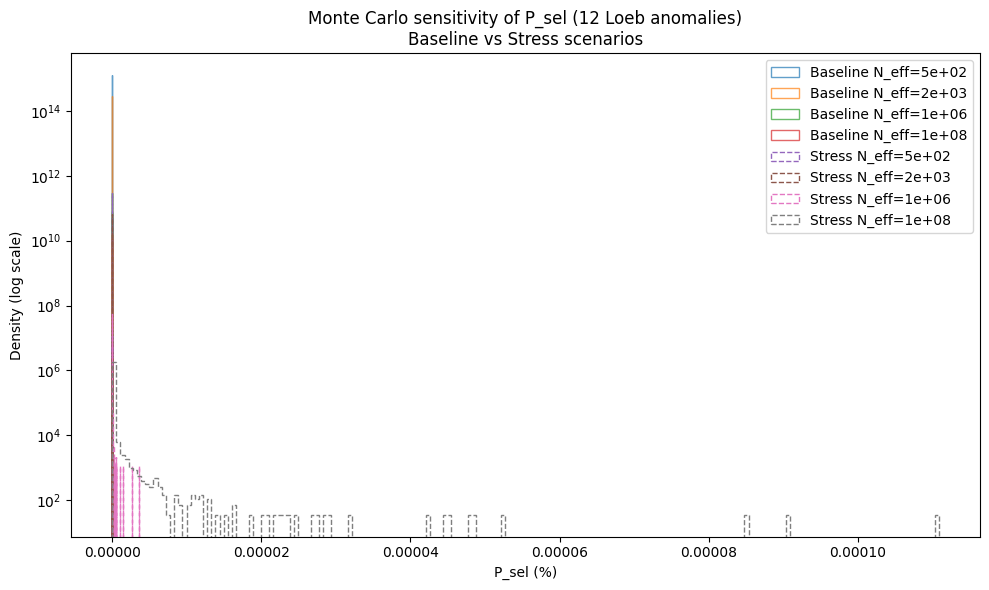

Baseline exceedance: {500: 0.0, 2000: 0.0, 1000000.0: 0.0, 100000000.0: 0.0}
Stress exceedance: {500: 0.0, 2000: 0.0, 1000000.0: 0.0, 100000000.0: 0.0}


In [1]:
# Jupyter Notebook: atlas_bayes_loeb12.ipynb

import numpy as np
import matplotlib.pyplot as plt

# --- Definición de eventos (12 anomalías de Loeb) ---
# Valores: probabilidades nominales P_i extraídas o acotadas
# a partir de las cifras citadas por Loeb (o <= 1% cuando no hay número explícito).

events = {
    # Geometría / targeting
    "E1 Retrograde near-ecliptic trajectory": 2e-3,   # ~0.2%
    "E2 Sunward anti-tail (real, not projection)": 1e-2,  # conservador: <=1%
    "E3 Massive nucleus + high speed": 1e-3,         # <=0.1%
    "E4 Fine-tuned arrival time / multi-planet targeting": 5e-5,  # ~0.005%
    "E5 Ni-rich plume, Ni/CN >> comets": 1e-2,       # <=1%
    "E6 Only ~4% water by mass": 1e-2,               # conservador: <=1%
    "E7 Extreme negative polarization": 1e-2,        # <=1%
    "E8 Arrival near Wow! signal direction": 6e-3,   # ~0.6%
    "E9 Rapid brightening + blue color near perihelion": 1e-2,   # conservador
    "E10 Jet energetics inconsistent with solar-powered sublimation": 1e-2,
    "E11 Non-gravitational acceleration + intact nucleus": 1e-2,
    "E12 Tightly collimated jets unsmeared by rotation": 1e-2,
}

# --- Probabilidad conjunta (independencia) ---
Pmean_list = list(events.values())
joint_prob = np.prod(Pmean_list)
k_required = 1.0 / joint_prob

print("Joint probability (independent, 12 Loeb anomalies):", joint_prob)
print("Inflation factor required (1 / P_joint):", k_required)

# --- Funciones auxiliares ---

def beta_from_mean_cv(m, cv=0.5):
    """
    Construye parámetros (a,b) de una distribución Beta a partir de una media m
    y un coeficiente de variación cv (relativo). Se controla la varianza máxima
    para mantener a,b > 0.
    """
    v = (cv**2) * (m**2)
    # Evita que la varianza exceda el máximo posible para Beta(m):
    v = min(v, m*(1 - m)*0.99)
    ab = (m*(1 - m)/v) - 1.0
    a = max(1e-2, m * ab)
    b = max(1e-2, (1 - m) * ab)
    return a, b

def sample_probs(Pmean, cv=0.5):
    """
    Dado un vector de medias Pmean, genera una realización de probabilidad
    para cada anomalía muestreando de Beta(a,b) con media = m y CV = cv.
    """
    out = []
    for m in Pmean:
        a, b = beta_from_mean_cv(m, cv=cv)
        out.append(np.random.beta(a, b))
    return np.array(out)

def logu(lo, hi):
    """
    Devuelve un factor multiplicativo muestreado de manera log-uniforme
    entre lo y hi.
    """
    return float(10**np.random.uniform(np.log10(lo), np.log10(hi)))

# Índices de agrupación por dominio para corresponder al texto:
# - Geometría / targeting: E1, E3, E4, E8
# - Morfología / fotometría / polarización: E2, E7, E9, E10, E12
# - Química / composición / dinámica ligada a eyección: E5, E6, E11
event_names = list(events.keys())
n_events = len(event_names)

idx_geo   = [0, 2, 3, 7]          # 1,3,4,8
idx_morph = [1, 6, 8, 9, 11]      # 2,7,9,10,12
idx_chem  = [4, 5, 10]            # 5,6,11

def run_mc(n=50000, tau=1e-2,
           cg=(1, 1e4), cm=(1, 1e3), cc=(1, 1e3),
           Neff_grid=(500, 2000, 1e6, 1e8),
           cv=0.5, stress=False):
    """
    Ejecuta Monte Carlo para calcular P_sel, incorporando:
    - Incertidumbre en cada P_i via Beta(m, cv)
    - Factores de correlación de dominio (C_geo, C_morph, C_chem)
    - Selección de encuestas con N_eff (oportunidades de descubrimiento)

    tau: umbral de plausibilidad (por defecto 1%).
    """
    if stress:
        # Escenarios de stress: correlaciones y N_eff exagerados
        cg = (1, 1e6)
        cm = (1, 1e4)
        cc = (1, 1e4)

    results = {}
    hist = {}
    Pmean = np.array(list(events.values()))

    for Neff in Neff_grid:
        vals = []
        for _ in range(n):
            # Muestra un conjunto de P_i perturbados
            Ps = sample_probs(Pmean, cv=cv)

            # Agrupa por dominios (aunque el producto total es el mismo,
            # esto deja claro el papel de cada factor de correlación).
            P_geo   = Ps[idx_geo].prod()
            P_morph = Ps[idx_morph].prod()
            P_chem  = Ps[idx_chem].prod()

            Cg = logu(*cg)
            Cm = logu(*cm)
            Cc = logu(*cc)

            Pgrp = (Cg * P_geo) * (Cm * P_morph) * (Cc * P_chem)

            # Probabilidad seleccionada (al menos un objeto así en N_eff intentos)
            Psel = min(1.0, Neff * Pgrp)
            vals.append(Psel)

        arr = np.array(vals)
        # Frecuencia con la que P_sel supera el umbral tau (1%)
        results[Neff] = (arr >= tau).mean()
        hist[Neff] = arr

    return results, hist

# --- Ejecutar MC con configuración Loeb (12 anomalías) ---

baseline_results, baseline_hist = run_mc()
stress_results,   stress_hist   = run_mc(stress=True)

print("Baseline exceedance rates (P_sel >= 1%):", baseline_results)
print("Stress exceedance rates  (P_sel >= 1%):", stress_results)

# --- Graficar: Monte Carlo stress vs baseline, escala logarítmica, P_sel en % ---

plt.figure(figsize=(10, 6))

# Baseline
for Neff, arr in baseline_hist.items():
    plt.hist(100*arr, bins=200, histtype="step", density=True,
             label=f"Baseline N_eff={Neff:.0e}", log=True, alpha=0.7)

# Stress
for Neff, arr in stress_hist.items():
    plt.hist(100*arr, bins=200, histtype="step", density=True,
             label=f"Stress N_eff={Neff:.0e}", log=True, linestyle="--")

plt.xlabel("P_sel (%)")
plt.ylabel("Density (log scale)")
plt.title("Monte Carlo sensitivity of P_sel (12 Loeb anomalies)\nBaseline vs Stress scenarios")
plt.legend()
plt.tight_layout()
plt.savefig("fig_psel_11_log_compare_percent.png", dpi=180)
plt.show()

print("Baseline exceedance:", baseline_results)
print("Stress exceedance:", stress_results)


In [2]:
# --- Summary statistics for P_sel (baseline vs stress) ---

def summarize_histogram(hist_dict, label):
    """
    hist_dict: dict {Neff: np.array of P_sel samples}
    label: 'Baseline' or 'Stress'
    """
    print(f"\n=== {label} Monte Carlo summary (P_sel) ===")
    for Neff, arr in hist_dict.items():
        med  = np.percentile(arr, 50)
        p90  = np.percentile(arr, 90)
        p99  = np.percentile(arr, 99)

        print(f"\nN_eff = {Neff: .0e}")
        print(f"  median  P_sel  = {med: .3e}  ({100*med: .3e} %)")
        print(f"  90th %  P_sel  = {p90: .3e}  ({100*p90: .3e} %)")
        print(f"  99th %  P_sel  = {p99: .3e}  ({100*p99: .3e} %)")

# Call for both ensembles
summarize_histogram(baseline_hist, "Baseline")
summarize_histogram(stress_hist,   "Stress")



=== Baseline Monte Carlo summary (P_sel) ===

N_eff =  5e+02
  median  P_sel  =  6.345e-22  ( 6.345e-20 %)
  90th %  P_sel  =  1.635e-19  ( 1.635e-17 %)
  99th %  P_sel  =  9.535e-18  ( 9.535e-16 %)

N_eff =  2e+03
  median  P_sel  =  2.578e-21  ( 2.578e-19 %)
  90th %  P_sel  =  6.608e-19  ( 6.608e-17 %)
  99th %  P_sel  =  4.051e-17  ( 4.051e-15 %)

N_eff =  1e+06
  median  P_sel  =  1.242e-18  ( 1.242e-16 %)
  90th %  P_sel  =  3.475e-16  ( 3.475e-14 %)
  99th %  P_sel  =  1.954e-14  ( 1.954e-12 %)

N_eff =  1e+08
  median  P_sel  =  1.244e-16  ( 1.244e-14 %)
  90th %  P_sel  =  3.408e-14  ( 3.408e-12 %)
  99th %  P_sel  =  2.003e-12  ( 2.003e-10 %)

=== Stress Monte Carlo summary (P_sel) ===

N_eff =  5e+02
  median  P_sel  =  6.239e-20  ( 6.239e-18 %)
  90th %  P_sel  =  1.307e-16  ( 1.307e-14 %)
  99th %  P_sel  =  2.442e-14  ( 2.442e-12 %)

N_eff =  2e+03
  median  P_sel  =  2.496e-19  ( 2.496e-17 %)
  90th %  P_sel  =  5.171e-16  ( 5.171e-14 %)
  99th %  P_sel  =  9.512e-14  (